In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import gget

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

sc.settings.verbosity = 3

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/geneformer/pseudotime_cell_embeddings.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 4.71 s, sys: 1.99 s, total: 6.7 s
Wall time: 10.1 s


AnnData object with n_obs × n_vars = 15867 × 512
    obs: 'input_ids', 'batch', 'phase', 'n_counts', 'mean_pseudotime', 'mean_order', 'nnz', 'S_score', 'G2M_score', 'cluster_str', 'length'
    uns: 'gene_df'
    obsm: 'X_draw_graph_fa', 'X_pca_harmony'

[2025-05-15 13:23:05.258] [CUML] [debug] n_neighbors=15
[2025-05-15 13:23:05.258] [CUML] [debug] Calling knn graph run
[2025-05-15 13:23:05.258] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-05-15 13:23:05.259] [CUML] [debug] Done. Calling remove zeros


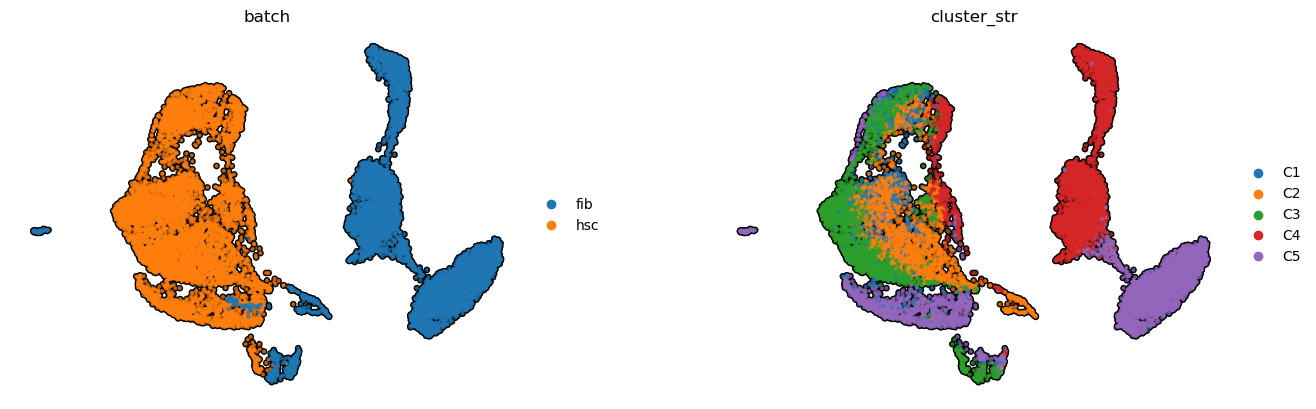

In [6]:
rsc.pp.neighbors(adata, use_rep='X')
rsc.tl.umap(adata)

sc.pl.umap(
    adata,
    color=['batch', 'cluster_str'],
    sort_order=True,
    size=32,
    ncols=4,
    alpha=0.75,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    colorbar_loc=None,
    wspace=0.25,
)

[2025-05-15 13:22:56.892] [CUML] [debug] n_neighbors=15
[2025-05-15 13:22:56.892] [CUML] [debug] Calling knn graph run
[2025-05-15 13:22:56.892] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-05-15 13:22:56.894] [CUML] [debug] Done. Calling remove zeros


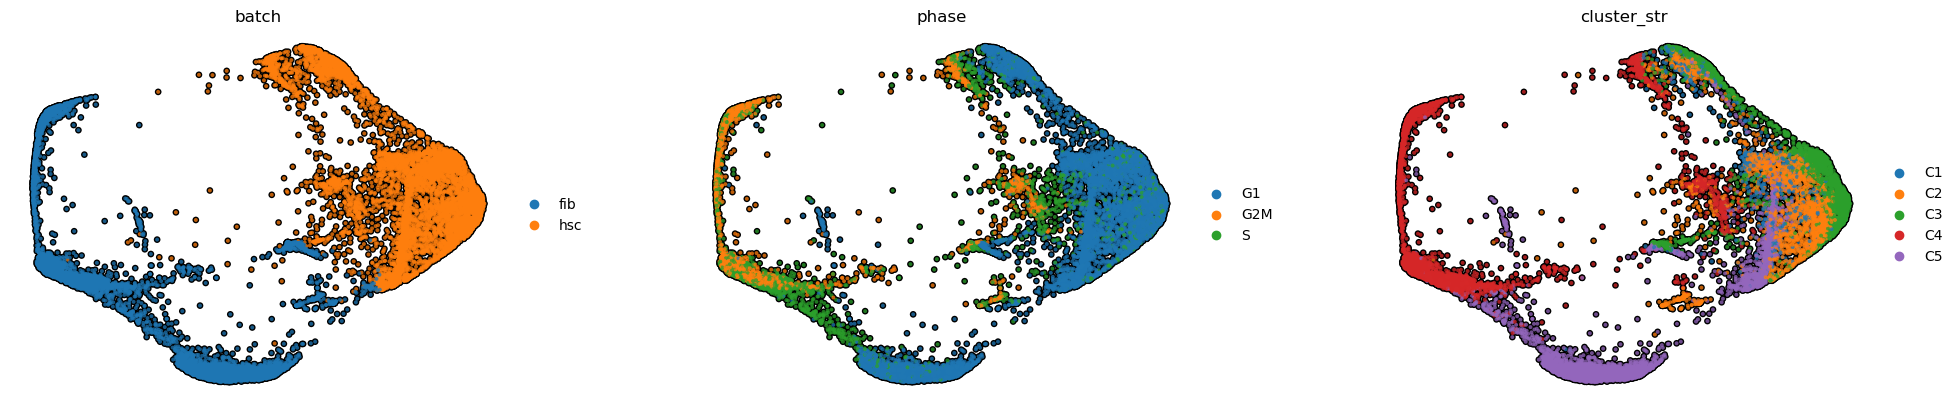

In [4]:
rsc.pp.neighbors(adata, use_rep='X')
rsc.tl.draw_graph(adata)

rsc.tl.umap(adata)
sc.pl.draw_graph(
    adata,
    color=['batch', 'phase', 'cluster_str'],
    sort_order=True,
    size=32,
    ncols=4,
    alpha=0.75,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    colorbar_loc=None,
    wspace=0.25,
)

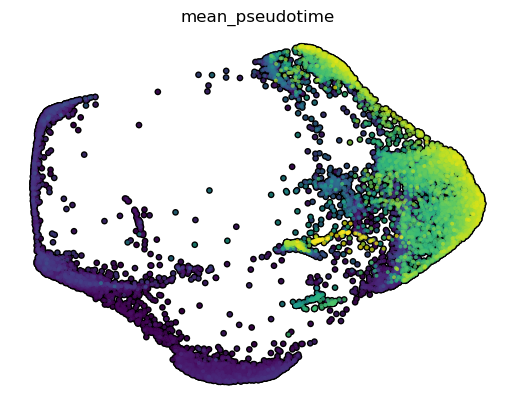

In [5]:
adata.obs['mean_pseudotime'] = adata.obs['mean_pseudotime'].astype(float)

sc.pl.draw_graph(
    adata,
    color=['mean_pseudotime'],
    sort_order=True,
    size=32,
    ncols=4,
    alpha=0.75,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    colorbar_loc=None,
    wspace=0.25,
)